In [6]:
# Dataset - https://www.kaggle.com/datasets/salader/dogs-vs-cats


In [7]:
!pip install kagglehub

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [9]:
import kagglehub

dataset_path = kagglehub.dataset_download("salader/dogsvscats")

print(dataset_path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
/kaggle/input/dogsvscats


In [10]:
import kagglehub

dataset_path = kagglehub.dataset_download("salader/dogsvscats")

print(dataset_path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
/kaggle/input/dogsvscats


In [11]:
import os
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

print("Train:", train_path)
print("Test :", test_path)

Train: /kaggle/input/dogsvscats/train
Test : /kaggle/input/dogsvscats/test


In [12]:
for split in ["train", "test"]:
    split_path = os.path.join(dataset_path, split)

    print(f"\n{split.upper()}")

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            print(class_name, ":", count)


TRAIN
dogs : 10000
cats : 10000

TEST
dogs : 2500
cats : 2500


Image: cat.12461.jpg
Size: (349, 352)
Mode: RGB


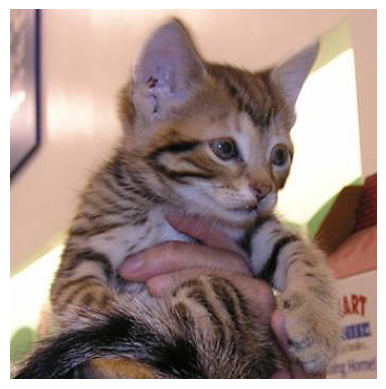

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

cat_path = os.path.join(train_path, "cats")

image_name = os.listdir(cat_path)[0]
image_path = os.path.join(cat_path, image_name)

img = Image.open(image_path)

print("Image:", image_name)
print("Size:", img.size)
print("Mode:", img.mode)

plt.imshow(img)
plt.axis("off")
plt.show()

Image: cat.10176.jpg
Size: (500, 374)
Mode: RGB


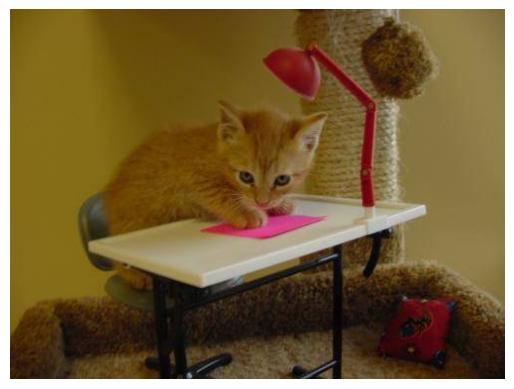

In [14]:
from PIL import Image
import matplotlib.pyplot as plt

cat_path = os.path.join(train_path, "cats")

image_name = os.listdir(cat_path)[1]
image_path = os.path.join(cat_path, image_name)

img = Image.open(image_path)

print("Image:", image_name)
print("Size:", img.size)
print("Mode:", img.mode)

plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

cat_folder = os.path.join(train_path, "cats")
dog_folder = os.path.join(train_path, "dogs")

cat_image = os.listdir(cat_folder)[0]
dog_image = os.listdir(dog_folder)[0]

cat_path = os.path.join(cat_folder, cat_image)
dog_path = os.path.join(dog_folder, dog_image)

cat_img = Image.open(cat_path)
dog_img = Image.open(dog_path)

print("Cat image:")
print("  File:", cat_image)
print("  Size:", cat_img.size)
print("  Mode:", cat_img.mode)

print("\nDog image:")
print("  File:", dog_image)
print("  Size:", dog_img.size)
print("  Mode:", dog_img.mode)

Cat image:
  File: cat.12461.jpg
  Size: (349, 352)
  Mode: RGB

Dog image:
  File: dog.3443.jpg
  Size: (320, 239)
  Mode: RGB


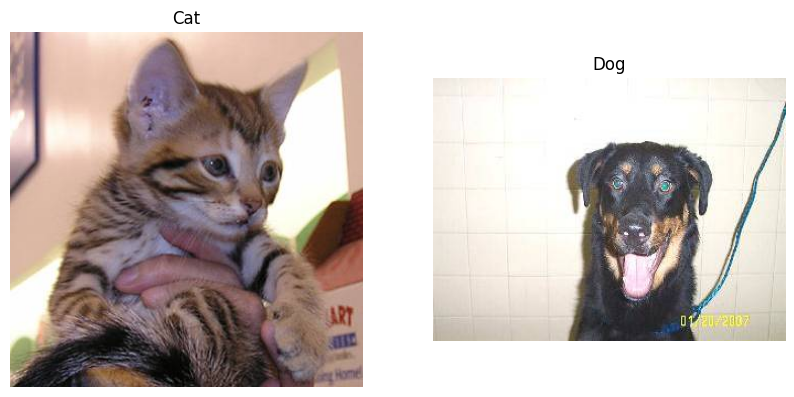

In [16]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cat_img)
plt.title("Cat")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dog_img)
plt.title("Dog")
plt.axis("off")

plt.show()

In [17]:
## we use teh keras that our memory t\load that is not in the system of the computer


In [18]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout


In [19]:
import tensorflow as tf

IMG_SIZE = (256, 256)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [20]:
print(train_ds.class_names)

['cats', 'dogs']


In [21]:
images, labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (32, 256, 256, 3)
Labels shape: (32, 1)


In [22]:
## normalization of the image

In [23]:
def process(image, label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label
train_ds = train_ds.map(process)
test_ds = test_ds.map(process)

In [24]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [25]:
## lets we build teh cnn model

In [42]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import (
    Dense,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling2D
)
model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(GlobalAveragePooling2D())

## then we make the fc layer (fully connect)
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

In [43]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,977 (464.75 KB)

 Trainable params: 118,529 (463.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [44]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [45]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [46]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.6345 - loss: 0.6320 - val_accuracy: 0.5442 - val_loss: 1.0807
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.7044 - loss: 0.5672 - val_accuracy: 0.6124 - val_loss: 0.8441
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.7358 - loss: 0.5309 - val_accuracy: 0.7322 - val_loss: 0.5360
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.7570 - loss: 0.4983 - val_accuracy: 0.7150 - val_loss: 0.5714
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.7902 - loss: 0.4556 - val_accuracy: 0.7380 - val_loss: 0.5455
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.8253 - loss: 0.3930 - val_accuracy: 0.6634 - val_loss: 1.5039
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8503 - loss: 0.3401 - val_accuracy: 0.8074 - val_loss: 0.4697
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.8699 - loss: 0.3017 - 

Training accuracy      89.49%
Training loss           0.2532

Validation accuracy    85.30%
Validation loss         0.3978

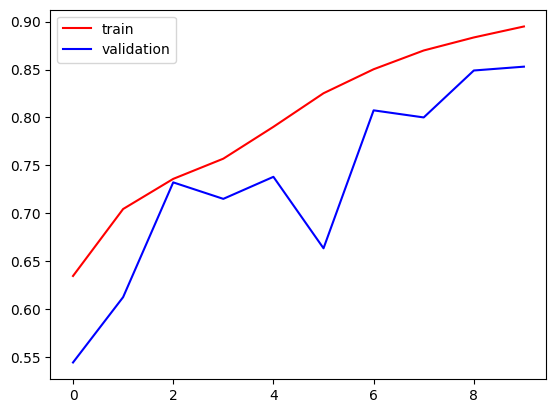

In [48]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

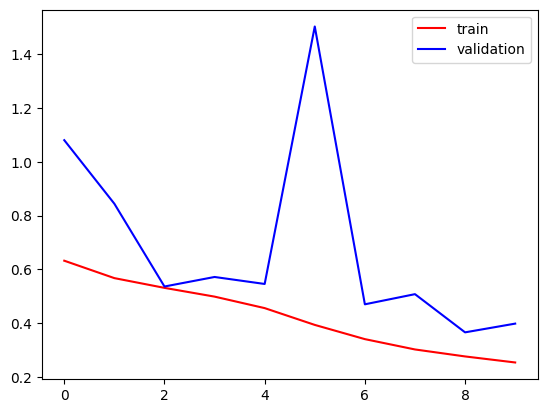

In [49]:

plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [50]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.8530 - loss: 0.3978
Test Loss: 0.39784249663352966
Test Accuracy: 0.8529999852180481


In [67]:
temp_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(256, 256),
    batch_size=32,
    label_mode="binary",
    shuffle=False
)

print(temp_ds.class_names)

Found 20000 files belonging to 2 classes.
['cats', 'dogs']


Raw prediction: 0.007122454233467579
Prediction: Cat
Confidence: 99.29%


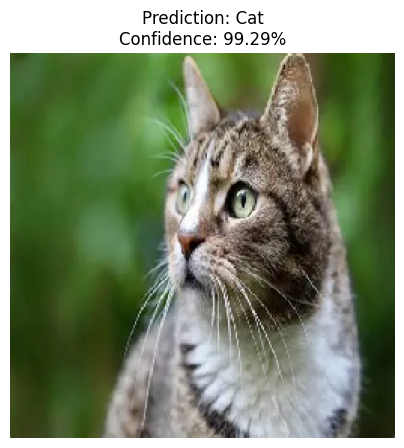

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

image_path = "/content/OIP (3).jpg"

# Load image
image = load_img(
    image_path,
    target_size=(256, 256)
)
image_array = img_to_array(image)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

# Prediction
prediction = model.predict(image_array, verbose=0)
probability = float(prediction[0][0])
if probability >= 0.5:
    predicted_class = "Dog"
    confidence = probability * 100
else:
    predicted_class = "Cat"
    confidence = (1 - probability) * 100
print("Raw prediction:", probability)
print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

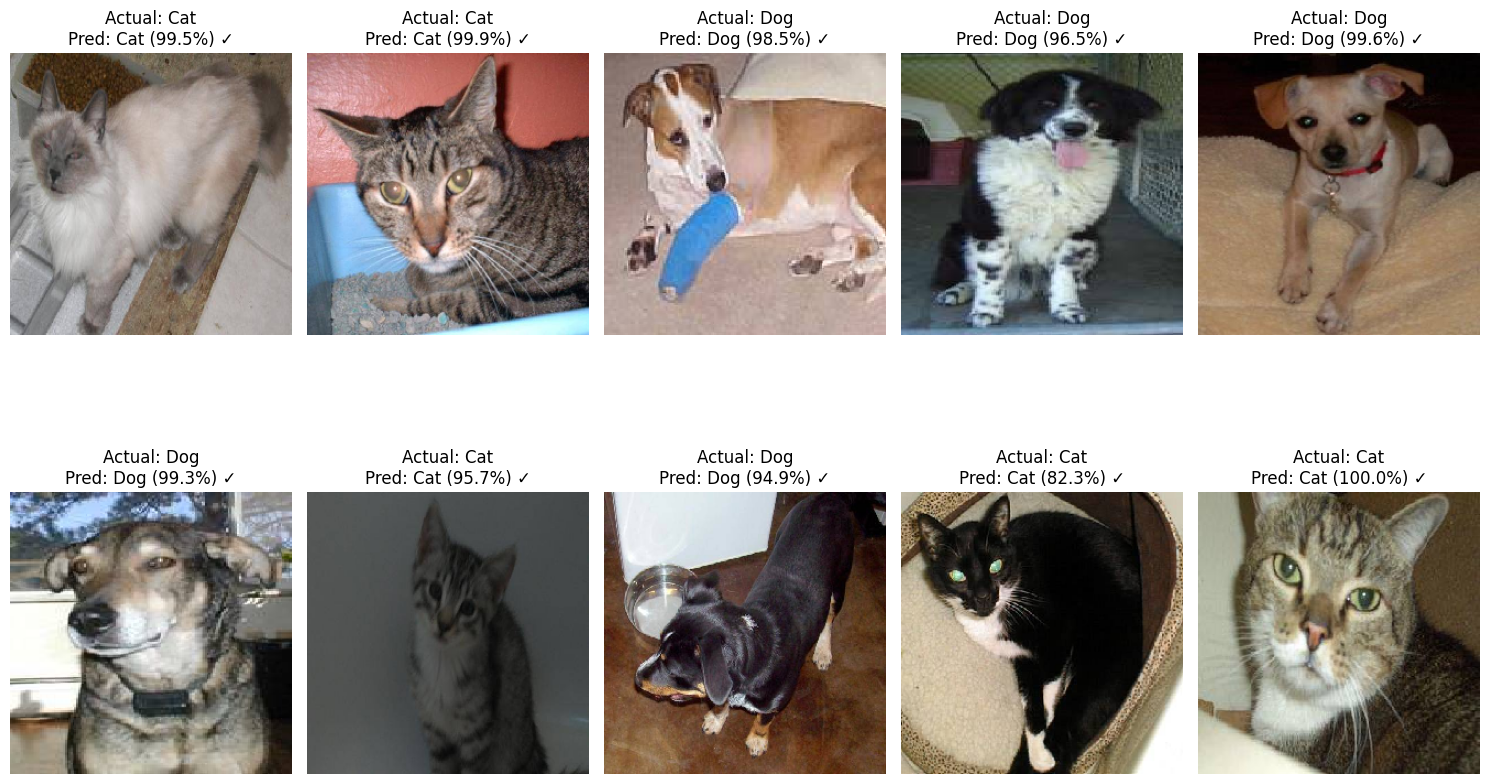

In [92]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# Paths
cat_path = os.path.join(train_path, "cats")
dog_path = os.path.join(train_path, "dogs")

# Select 5 random images from each class
cat_images = random.sample(os.listdir(cat_path), 5)
dog_images = random.sample(os.listdir(dog_path), 5)

image_paths = []

for img in cat_images:
    image_paths.append((os.path.join(cat_path, img), "Cat"))

for img in dog_images:
    image_paths.append((os.path.join(dog_path, img), "Dog"))

# Shuffle them
random.shuffle(image_paths)

# Plot
plt.figure(figsize=(15, 10))

for i, (image_path, actual_class) in enumerate(image_paths):

    # Load image
    image = load_img(image_path, target_size=(256, 256))

    # Convert to array
    image_array = img_to_array(image) / 255.0

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Prediction
    prediction = model.predict(image_array, verbose=0)
    probability = float(prediction[0][0])

    # Class
    if probability >= 0.5:
        predicted_class = "Dog"
        confidence = probability * 100
    else:
        predicted_class = "Cat"
        confidence = (1 - probability) * 100

    # Correct / Wrong
    result = "✓" if predicted_class == actual_class else "✗"

    # Display
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Actual: {actual_class}\n"
        f"Pred: {predicted_class} ({confidence:.1f}%) {result}"
    )

plt.tight_layout()
plt.show()

Confusion Matrix:
[[2200  300]
 [ 435 2065]]


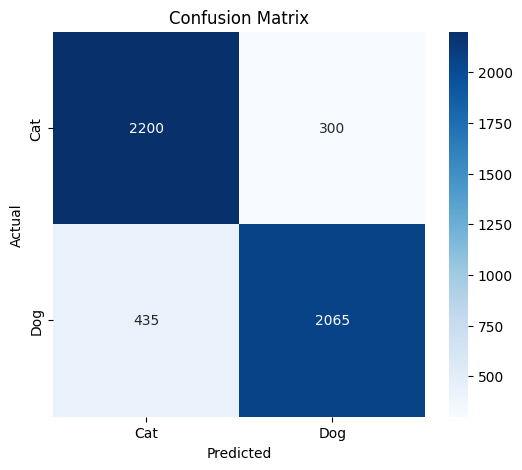

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    predictions = (predictions >= 0.5).astype(int).flatten()

    y_pred.extend(predictions)
    y_true.extend(labels.numpy().astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [94]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))

              precision    recall  f1-score   support

         Cat       0.83      0.88      0.86      2500
         Dog       0.87      0.83      0.85      2500

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



/tmp/ipykernel_2758/2756557940.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = int(labels[i].numpy())


Total misclassified images: 735


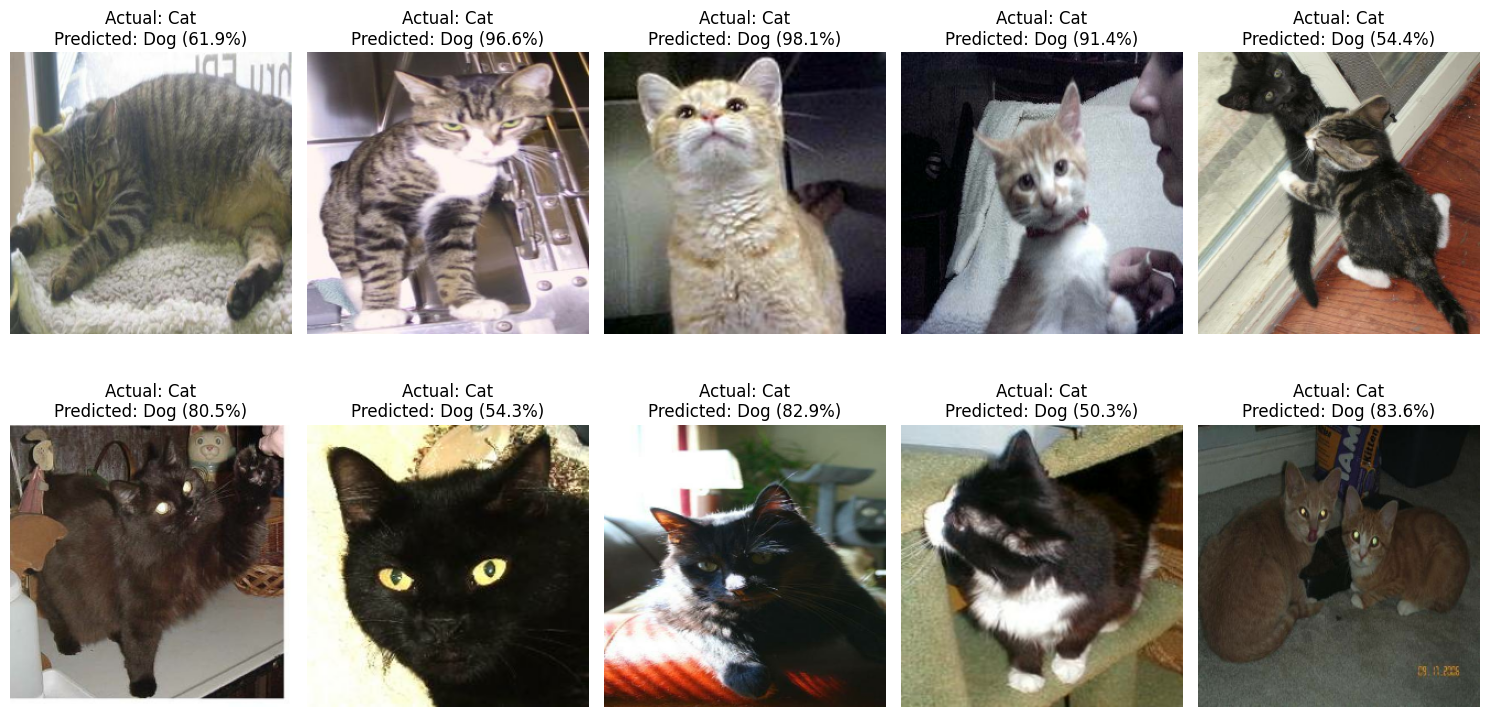

In [95]:
import numpy as np
import matplotlib.pyplot as plt

class_names = ["Cat", "Dog"]

wrong_images = []
wrong_actual = []
wrong_predicted = []
wrong_confidence = []

# Go through test dataset
for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    for i in range(len(images)):

        probability = float(predictions[i][0])

        # Prediction
        if probability >= 0.5:
            predicted = 1
            confidence = probability
        else:
            predicted = 0
            confidence = 1 - probability

        actual = int(labels[i].numpy())

        # Store only wrong predictions
        if predicted != actual:

            wrong_images.append(images[i].numpy())
            wrong_actual.append(actual)
            wrong_predicted.append(predicted)
            wrong_confidence.append(confidence)

# Number of mistakes
print("Total misclassified images:", len(wrong_images))

# Display first 10 mistakes
num_images = min(10, len(wrong_images))

plt.figure(figsize=(15, 8))

for i in range(num_images):

    plt.subplot(2, 5, i + 1)

    plt.imshow(wrong_images[i])
    plt.axis("off")

    actual = class_names[wrong_actual[i]]
    predicted = class_names[wrong_predicted[i]]
    confidence = wrong_confidence[i] * 100

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted} ({confidence:.1f}%)"
    )

plt.tight_layout()
plt.show()